In [1]:
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px

In [2]:
# Przygotowanie i filtrowanie danych
df = pd.read_csv('incidents.csv', low_memory=False)
df['datetime'] = pd.to_datetime(df['datetime'], format='ISO8601')
df

,id,datetime,longitude,latitude,voivodeship,county,municipality,city,incident_type,other_cause,...,vehicle_types_trucks,vehicle_types_semi-trailer_tractors,road_accidents_total_accidents,road_accidents_total_casualties,road_accidents_fatalities,road_accidents_injured,road_types_municipal_and_county_paved_roads_per_100km2,road_types_municipal_and_county_paved_roads_per_10.000_inhabitants,precipation,precipation_24h
0,108526474,2020-01-01 00:15:00,16.761389,52.514028,wielkopolskie,poznański,Rokietnica,Rokietnica,Najechanie na pieszego,Brak,...,43349.0,10671.0,365.0,NaN,21.0,464.0,97.2,42.9,0.0,0.0
1,108526534,2020-01-01 00:20:00,18.953917,51.895527,łódzkie,poddębicki,Poddębice,Poddębice,Najechanie na pieszego,Brak,...,5163.0,262.0,42.0,NaN,2.0,59.0,73.0,160.7,0.0,0.0
2,108523125,2020-01-01 00:25:00,14.568027,53.435666,zachodniopomorskie,Szczecin,Szczecin,Szczecin,Zderzenie pojazdów boczne,Brak,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
3,108523133,2020-01-01 00:55:00,20.929499,53.849416,warmińsko-mazurskie,olsztyński,Biskupiec,Rzeck,Najechanie na drzewo,Brak,...,10951.0,669.0,135.0,NaN,8.0,172.0,38.2,84.3,0.0,0.0
4,108526549,2020-01-01 01:20:00,23.047500,53.405555,podlaskie,moniecki,Jasionówka,Brak w danych źródłowych,Wywrócenie się pojazdu,Brak,...,2807.0,234.0,22.0,NaN,1.0,26.0,40.1,143.3,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88602,125862934,2023-12-31 21:39:00,16.966860,50.850805,dolnośląskie,strzeliński,Borów,Głownin,Najechanie na drzewo,NaN,...,4419.0,421.0,23.0,27.0,4.0,23.0,79.1,117.7,0.0,0.0
88603,125860432,2023-12-31 22:20:00,19.934027,50.074999,małopolskie,Kraków,Kraków,Kraków,Najechanie na pojazd unieruchomiony,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0
88604,125862027,2023-12-31 23:16:00,20.519268,52.259491,mazowieckie,warszawski zachodni,Kampinos,Wiejca,Najechanie na drzewo,NaN,...,25941.0,5565.0,48.0,59.0,9.0,50.0,128.8,50.8,0.0,0.0
88605,125860445,2023-12-31 23:26:00,17.918390,50.673988,opolskie,Opole,Opole,Opole,Zderzenie pojazdów boczne,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0


In [3]:
# Filtry: tylko 2022 rok + usuwanie wierszy z brakami w kluczowych kolumnach
cols = ['road_type', 'surface_condition', 'incident_type']
df_2022 = df[df["datetime"].dt.year == 2022].dropna(subset=cols).copy()
df_2022.head()

,id,datetime,longitude,latitude,voivodeship,county,municipality,city,incident_type,other_cause,...,vehicle_types_trucks,vehicle_types_semi-trailer_tractors,road_accidents_total_accidents,road_accidents_total_casualties,road_accidents_fatalities,road_accidents_injured,road_types_municipal_and_county_paved_roads_per_100km2,road_types_municipal_and_county_paved_roads_per_10.000_inhabitants,precipation,precipation_24h
46355,116759838,2022-01-01 00:24:00,22.996222,52.193583,mazowieckie,łosicki,Stara Kornica,Wólka Nosowska,Najechanie na drzewo,Brak,...,3876.0,1741.0,13.0,NaN,5.0,18.0,69.8,186.3,0.2,0.2
46356,116757283,2022-01-01 01:09:00,19.218944,53.100167,kujawsko-pomorskie,golubsko-dobrzyński,Radomin,Rętwiny,Najechanie na drzewo,Brak,...,4278.0,633.0,32.0,NaN,4.0,38.0,117.1,164.8,0.1,0.1
46357,116757286,2022-01-01 01:25:00,21.123444,51.442194,mazowieckie,Radom,Radom,Radom,Najechanie na pieszego,Brak,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.2,1.1
46358,116759841,2022-01-01 01:28:00,21.150250,51.383166,mazowieckie,Radom,Radom,Radom,Najechanie na pieszego,Brak,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.2,1.1
46359,116764859,2022-01-01 01:30:00,20.888250,51.827388,mazowieckie,grójecki,Grójec,Turowice,Najechanie na pieszego,Brak,...,25676.0,1828.0,95.0,NaN,8.0,142.0,101.7,132.4,0.0,0.1


In [4]:
# Uproszczenie kategorii (Top 8 dla incident_type, by uniknąć chaosu)
top_incidents = df_2022['incident_type'].value_counts().nlargest(8).index
df_2022 = df_2022[df_2022['incident_type'].isin(top_incidents)]
df_2022.head()

,id,datetime,longitude,latitude,voivodeship,county,municipality,city,incident_type,other_cause,...,vehicle_types_trucks,vehicle_types_semi-trailer_tractors,road_accidents_total_accidents,road_accidents_total_casualties,road_accidents_fatalities,road_accidents_injured,road_types_municipal_and_county_paved_roads_per_100km2,road_types_municipal_and_county_paved_roads_per_10.000_inhabitants,precipation,precipation_24h
46355,116759838,2022-01-01 00:24:00,22.996222,52.193583,mazowieckie,łosicki,Stara Kornica,Wólka Nosowska,Najechanie na drzewo,Brak,...,3876.0,1741.0,13.0,NaN,5.0,18.0,69.8,186.3,0.2,0.2
46356,116757283,2022-01-01 01:09:00,19.218944,53.100167,kujawsko-pomorskie,golubsko-dobrzyński,Radomin,Rętwiny,Najechanie na drzewo,Brak,...,4278.0,633.0,32.0,NaN,4.0,38.0,117.1,164.8,0.1,0.1
46357,116757286,2022-01-01 01:25:00,21.123444,51.442194,mazowieckie,Radom,Radom,Radom,Najechanie na pieszego,Brak,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.2,1.1
46358,116759841,2022-01-01 01:28:00,21.150250,51.383166,mazowieckie,Radom,Radom,Radom,Najechanie na pieszego,Brak,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.2,1.1
46359,116764859,2022-01-01 01:30:00,20.888250,51.827388,mazowieckie,grójecki,Grójec,Turowice,Najechanie na pieszego,Brak,...,25676.0,1828.0,95.0,NaN,8.0,142.0,101.7,132.4,0.0,0.1


In [5]:
# Definicja kolorów (Paleta Qualitative)
unique_source = df_2022[cols[0]].unique()
unique_mid = df_2022[cols[1]].unique()
palette = px.colors.qualitative.Prism + px.colors.qualitative.Safe

# Mapowanie kolorów dla węzłów
color_map = {cat: palette[i % len(palette)] for i, cat in enumerate(list(unique_source) + list(unique_mid))}

In [6]:
# Przygotowanie struktury Sankey
nodes = []
for col in cols:
    nodes.extend(df_2022[col].unique().tolist())
nodes = list(dict.fromkeys(nodes))
mapping = {name: i for i, name in enumerate(nodes)}

sources, targets, values, link_colors = [], [], [], []

In [7]:
# road_type -> surface_condition
res1 = df_2022.groupby(['road_type', 'surface_condition']).size().reset_index(name='count')
for _, row in res1.iterrows():
    sources.append(mapping[row['road_type']])
    targets.append(mapping[row['surface_condition']])
    values.append(row['count'])
    # Kolor linku dziedziczony po road_type
    c = color_map[row['road_type']]
    link_colors.append(c.replace('rgb', 'rgba').replace(')', ', 0.5)'))

In [8]:
# surface_condition -> incident_type
res2 = df_2022.groupby(['surface_condition', 'incident_type']).size().reset_index(name='count')
for _, row in res2.iterrows():
    sources.append(mapping[row['surface_condition']])
    targets.append(mapping[row['incident_type']])
    values.append(row['count'])
    # Kolor linku dziedziczony po surface_condition
    c = color_map[row['surface_condition']]
    link_colors.append(c.replace('rgb', 'rgba').replace(')', ', 0.5)'))

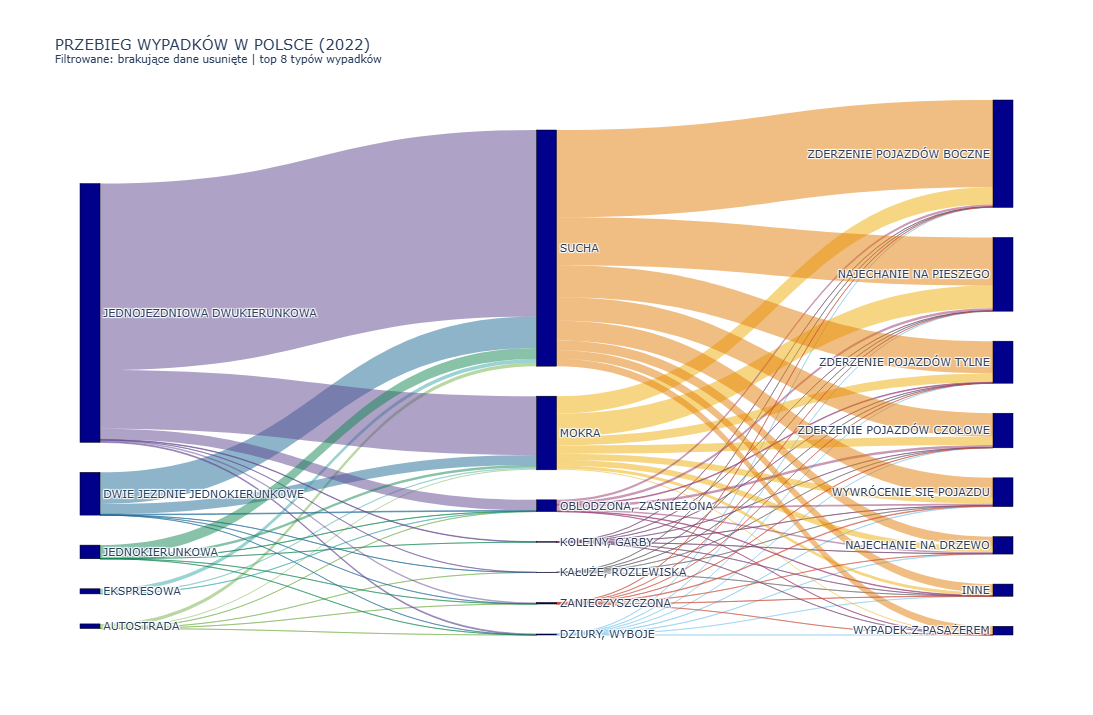

In [10]:
# Wykres
fig = go.Figure(go.Sankey(
    arrangement = "perpendicular",
    node = dict(
        pad = 30, thickness = 20,
        line = dict(color = "black", width = 0.5),
        label = [n.upper() for n in nodes],
        color = "darkblue"
    ),
    link = dict(
        source = sources, target = targets, 
        value = values, color = link_colors
    )
))

fig.update_layout(
    title_text="PRZEBIEG WYPADKÓW W POLSCE (2022)<br><sup>Filtrowane: brakujące dane usunięte | top 8 typów wypadków</sup>",
    font=dict(size=11),
    width=1100, height=700
)

fig.write_html("analiza_wypadkow_2022.html")
fig.show()